# Position servo

The PMSM as stepper and servo, ring and sag measured.

In [1]:
SIMULATED = True          # False, and PORT, at the bench
PORT = 'COM4'

In [2]:
from coaxial import Coaxial63100

device = Coaxial63100(port=PORT, simulated_device=SIMULATED).open()
print(device)

<Coaxial63100 Simulated SIMULATED>


HOLD holds a current vector at a commanded angle and the rotor is dragged along by the load-angle spring, `amps kt sin(delta)`: a microstepper. Open loop, so an overload slips poles silently. The servo is the same move with the slip measured out over the A1335.

On the `model` source the shaft sensor follows the rotor the drive torques, so the whole loop closes.

In [3]:
device.drive.source('model')
device.drive.model_param(j=2e-5, b=1e-5, load=0.0)
stage = device.gates.arm(bypass_sto=True, ignore_interlock=True)
print('armed', stage['pwm_enabled'])
print('pole pairs', device.drive.params()['motor_pole_pairs'])

armed True
pole pairs 7.0


In [4]:
import time

def trace(seconds, every=0.02):
    rows = []
    t0 = time.monotonic()
    while time.monotonic() - t0 < seconds:
        rows.append((time.monotonic() - t0, device.angle.state()['degrees']))
        time.sleep(every)
    return rows

with device.motion.stepper(amps=2.0, deg_s=90.0) as m:
    print('detented; command at %.2f deg' % m.position)
    m.to(90.0)
    ring = trace(0.6)
    print('command %.1f deg, shaft %.1f deg' % (m.position, ring[-1][1] - ring[0][1] + 0.0))
    m.step(10)
    print('ten full steps: command %.1f deg' % m.position)

detented; command at 0.00 deg


command 90.0 deg, shaft 0.4 deg


ten full steps: command 108.0 deg


The ring after a move: the shaft sampled at 50 Hz while the spring settles. Mechanical degrees, from where the block began.

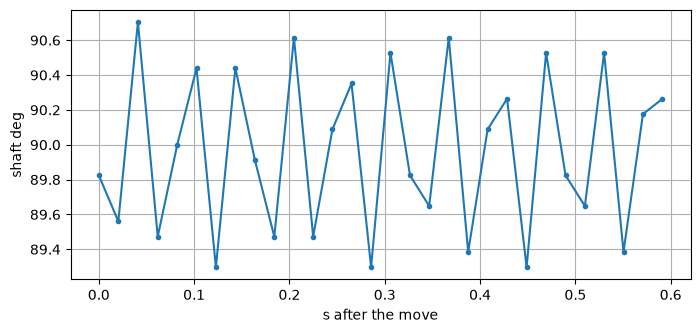

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot([r[0] for r in ring], [r[1] for r in ring], '.-')
ax.set_xlabel('s after the move'); ax.set_ylabel('shaft deg'); ax.grid(True)
plt.show()

The servo corrects what the load stole: move, settle, measure, correct, until inside `tol`. A load on the model makes the spring sag; `error` is target minus shaft from the last correction.

In [6]:
with device.motion.servo(amps=2.0, settle=0.3) as s:
    got = s.to(45.0, tol=0.5)
    print('no load:   shaft %.2f deg, error %.2f' % (got, s.error))
    device.drive.model_param(load=0.02)
    time.sleep(0.4)
    sag = s.to(45.0, tol=0.5)
    print('0.02 N.m:  shaft %.2f deg, error %.2f' % (sag, s.error))
    device.drive.model_param(load=0.0)
print(device.gates.disarm()['pwm_enabled'])
device.drive.source('adc')
device.close()

no load:   shaft 44.98 deg, error 0.02


0.02 N.m:  shaft 45.13 deg, error -0.13
False


## Conclusions

In [7]:
import math

peak = max(r[1] for r in ring)
floor = min(r[1] for r in ring)
print('ring after a 90 deg move   %.2f deg peak to peak over %.2f s'
      % (peak - floor, ring[-1][0]))
print('sampled at                 %.0f Hz' % (len(ring) / ring[-1][0]))
print('servo, no load             error %.2f deg' % (45.0 - got))
print('servo, 0.02 N.m            error %.2f deg' % (45.0 - sag))
print('holding torque             %.1f A x Kt' % 2.0)

ring after a 90 deg move   1.41 deg peak to peak over 0.59 s
sampled at                 51 Hz
servo, no load             error 0.02 deg
servo, 0.02 N.m            error -0.13 deg
holding torque             2.0 A x Kt


Two verbs, one loop. `_slew_to` walks the command at `pitch` mechanical degrees a write, so the spring is never asked to span more than a few degrees at once - the stepper's move and the servo's correction are the same code, not two copies of it.

`_energize` ramps the current over a few writes instead of snapping it on: full current onto an unknown rotor is a yank of up to half a pole that an underdamped rotor rides straight through, pole after pole. Grown slowly it detents into the nearest pole and stays, and where it stops is where angles count from.

The servo closes **once per move**, not per pass. This link corrects at tens of hertz and the load-angle spring rings at tens of hertz, so a per-pass loop samples its own resonance aliased and pumps it - six clean passes wound the rotor through a pole slip into a freewheel. The honest shape is a stepper with the slip measured out: slew, let the ring die, read, correct.

The zero and every correction are a **mean** of nine reads: the detent rings, and one read froze up to the ring's amplitude into the frame for the life of the block. `to()` raises after `tries` corrections still outside `tol` - a stalled arm is a fact, not a return code (invariant 8).